# Media Authenticity Detection - MesoNet4

**Model:** MesoNet4 — tiny CNN designed specifically for deepfake detection.
- Only ~27K parameters → **trains in minutes even on CPU**
- No transfer learning needed
- Batch Size: 64 | Image: 128×128 | 20 epochs | Auto-resume

In [1]:
import os, gc, re, glob, json, pickle
import tensorflow as tf
from tensorflow.keras import layers, callbacks
import matplotlib.pyplot as plt
import multiprocessing

NUM_CORES = multiprocessing.cpu_count()
tf.config.threading.set_intra_op_parallelism_threads(NUM_CORES)
tf.config.threading.set_inter_op_parallelism_threads(NUM_CORES)
print(f"TF: {tf.__version__} | Cores: {NUM_CORES}")

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    from tensorflow.keras import mixed_precision
    mixed_precision.set_global_policy('mixed_float16')
else:
    tf.config.set_visible_devices([], 'GPU')
    print("No GPU. CPU optimizations active.")

BASE_DIR        = os.path.join("..", "data", "processed", "images")
MODEL_SAVE_PATH = os.path.join("..", "models", "mesonet_model.keras")
MODEL_PKL_PATH  = os.path.join("..", "models", "mesonet_model.pkl")
CHECKPOINT_DIR  = os.path.join("..", "models", "checkpoints_mesonet")
STATE_FILE      = os.path.join(CHECKPOINT_DIR, "training_state.json")
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

IMAGE_SIZE = (128, 128)
BATCH_SIZE = 64    # MesoNet is tiny — large batch is fine and fast
EPOCHS     = 20
print(f"Image: {IMAGE_SIZE}, Batch: {BATCH_SIZE}, Steps/epoch: {70000//BATCH_SIZE}")

TF: 2.21.0 | Cores: 12
No GPU. CPU optimizations active.
Image: (128, 128), Batch: 64, Steps/epoch: 1093


In [2]:
def find_latest_checkpoint():
    files = glob.glob(os.path.join(CHECKPOINT_DIR, "mesonet_epoch_*.keras"))
    if not files: return None, 0
    def ep(f): m = re.search(r'epoch_(\d+)', f); return int(m.group(1)) if m else 0
    files.sort(key=ep)
    return files[-1], ep(files[-1])

def load_training_state():
    if os.path.exists(STATE_FILE):
        with open(STATE_FILE) as f: s = json.load(f)
        print(f"[State] {s}"); return s
    print("[State] Fresh start."); return {"last_completed_epoch": 0}

def save_training_state(epoch, val_loss=None):
    s = {"last_completed_epoch": epoch}
    if val_loss: s["best_val_loss"] = round(float(val_loss), 6)
    with open(STATE_FILE, 'w') as f: json.dump(s, f, indent=2)

class StateLogger(tf.keras.callbacks.Callback):
    def __init__(self, initial_epoch=0):
        super().__init__(); self.initial_epoch = initial_epoch
    def on_epoch_end(self, epoch, logs=None):
        abs_ep = self.initial_epoch + epoch + 1
        save_training_state(abs_ep, logs.get('val_loss') if logs else None)
        print(f"  [StateLogger] epoch={abs_ep}")

print("Helpers loaded.")

Helpers loaded.


In [3]:
AUTOTUNE = tf.data.AUTOTUNE
train_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(BASE_DIR,'train'), image_size=IMAGE_SIZE, batch_size=BATCH_SIZE, label_mode='binary'
)
class_names = train_ds.class_names
train_ds = train_ds.shuffle(1000).prefetch(AUTOTUNE)

val_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(BASE_DIR,'val'), image_size=IMAGE_SIZE, batch_size=BATCH_SIZE, label_mode='binary'
).prefetch(AUTOTUNE)

test_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(BASE_DIR,'test'), image_size=IMAGE_SIZE, batch_size=BATCH_SIZE, label_mode='binary'
).prefetch(AUTOTUNE)

gc.collect()
print(f"Classes: {class_names}")

Found 70000 files belonging to 2 classes.
Found 15000 files belonging to 2 classes.
Found 15000 files belonging to 2 classes.
Classes: ['fake', 'real']


## MesoNet4 Architecture
4 blocks: Conv → BN → MaxPool, then FC head. Only **~27K params**.

In [4]:
def build_mesonet4(input_shape=(128, 128, 3)):
    inputs = tf.keras.Input(shape=input_shape)
    x = layers.Rescaling(1./255)(inputs)
    # Block 1
    x = layers.Conv2D(8, (3,3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2,2), padding='same')(x)
    # Block 2
    x = layers.Conv2D(8, (5,5), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2,2), padding='same')(x)
    # Block 3
    x = layers.Conv2D(16, (5,5), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2,2), padding='same')(x)
    # Block 4
    x = layers.Conv2D(16, (5,5), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((4,4), padding='same')(x)
    # Head
    x = layers.Flatten()(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(16)(x)
    x = layers.LeakyReLU(negative_slope=0.1)(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)
    return tf.keras.Model(inputs, outputs, name='MesoNet4')

model = build_mesonet4()
model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
              loss='binary_crossentropy', metrics=['accuracy'])
model.summary()
print(f"Total params: {model.count_params():,}")

Model: "MesoNet4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 8)    │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 8)    │            32 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 8)      │         1,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 8)      │            32 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 16)     │         3,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 16)     │         6,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 4, 4, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │         4,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,785 (61.66 KB)

 Trainable params: 15,689 (61.29 KB)

 Non-trainable params: 96 (384.00 B)

Total params: 15,785


## Training (Resume-Aware)

In [5]:
state = load_training_state()
ckpt_file, ckpt_epoch = find_latest_checkpoint()
initial_epoch = state["last_completed_epoch"]

if ckpt_file and initial_epoch > 0:
    model.load_weights(ckpt_file)
    print(f"Resuming from epoch {initial_epoch} ({os.path.basename(ckpt_file)})")
elif ckpt_file and ckpt_epoch > 0:
    model.load_weights(ckpt_file); initial_epoch = ckpt_epoch
    print(f"Resuming from checkpoint epoch {initial_epoch}")
else:
    print("Starting MesoNet4 from scratch.")

print(f"=== MesoNet4 | Epochs: {initial_epoch+1} → {EPOCHS} ===")
history = model.fit(
    train_ds, validation_data=val_ds,
    epochs=EPOCHS, initial_epoch=initial_epoch,
    callbacks=[
        callbacks.ModelCheckpoint(
            os.path.join(CHECKPOINT_DIR, "mesonet_epoch_{epoch:02d}.keras"),
            save_best_only=True, monitor='val_loss', verbose=1),
        callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
        callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6, verbose=1),
        StateLogger(initial_epoch=initial_epoch)
    ]
)
gc.collect()
print("Training complete.")

[State] {'last_completed_epoch': 9, 'best_val_loss': 0.151312}
Resuming from epoch 9 (mesonet_epoch_09.keras)
=== MesoNet4 | Epochs: 10 → 20 ===
Epoch 10/20


D:\Media Validate App\.venv\Lib\site-packages\keras\src\saving\saving_lib.py:801: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 42 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


1094/1094 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step - accuracy: 0.9379 - loss: 0.1745
Epoch 10: val_loss improved from None to 0.17411, saving model to ..\models\checkpoints_mesonet\mesonet_epoch_10.keras

Epoch 10: finished saving model to ..\models\checkpoints_mesonet\mesonet_epoch_10.keras
  [StateLogger] epoch=19
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 227s 171ms/step - accuracy: 0.9358 - loss: 0.1763 - val_accuracy: 0.9341 - val_loss: 0.1741 - learning_rate: 0.0010
Epoch 11/20
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 0s 265ms/step - accuracy: 0.9362 - loss: 0.1727
Epoch 11: val_loss improved from 0.17411 to 0.16483, saving model to ..\models\checkpoints_mesonet\mesonet_epoch_11.keras

Epoch 11: finished saving model to ..\models\checkpoints_mesonet\mesonet_epoch_11.keras
  [StateLogger] epoch=20
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 380s 286ms/step - accuracy: 0.9368 - loss: 0.1729 - val_accuracy: 0.9376 - val_loss: 0.1648 - learning_rate: 0.0010
Epoch 12/20
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 0s 256ms/step - accuracy

In [6]:
test_loss, test_acc = model.evaluate(test_ds)
print(f"\nTest Accuracy: {test_acc:.4f} | Test Loss: {test_loss:.4f}")
model.save(MODEL_SAVE_PATH)
print(f"Saved to {MODEL_SAVE_PATH}")
try:
    with open(MODEL_PKL_PATH, 'wb') as f: pickle.dump(model, f)
    print(f"Pickle saved to {MODEL_PKL_PATH}")
except Exception as e:
    print(f"Pickle failed: {e}")

235/235 ━━━━━━━━━━━━━━━━━━━━ 23s 96ms/step - accuracy: 0.9509 - loss: 0.1320

Test Accuracy: 0.9509 | Test Loss: 0.1320
Saved to ..\models\mesonet_model.keras
Pickle saved to ..\models\mesonet_model.pkl


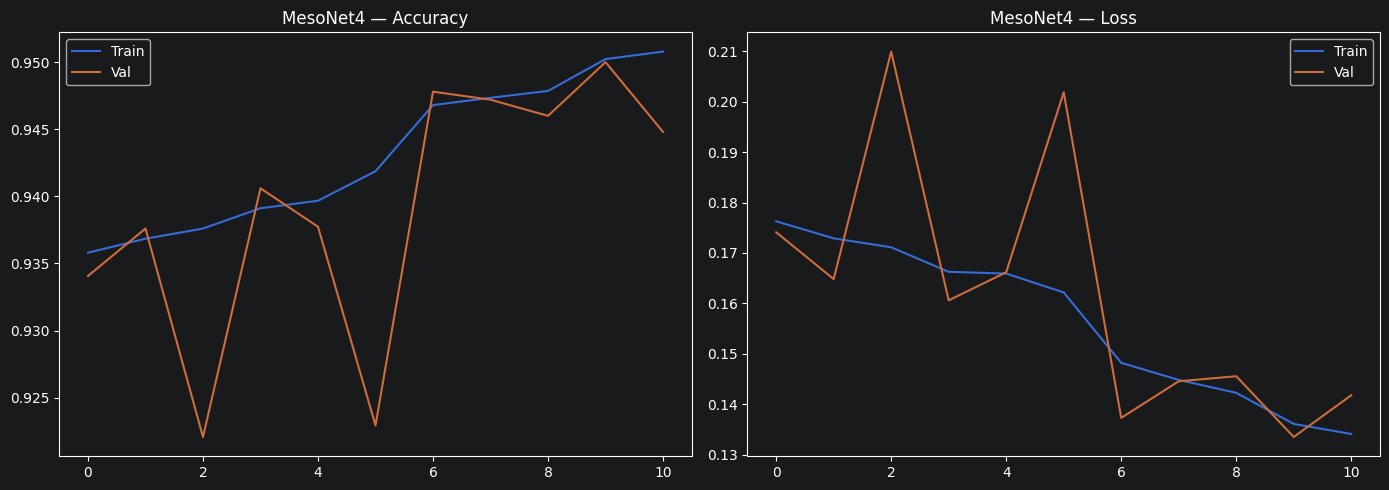

Plot saved.


In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(history.history.get('accuracy', []), label='Train'); ax1.plot(history.history.get('val_accuracy', []), label='Val')
ax1.set_title('MesoNet4 — Accuracy'); ax1.legend()
ax2.plot(history.history.get('loss', []), label='Train'); ax2.plot(history.history.get('val_loss', []), label='Val')
ax2.set_title('MesoNet4 — Loss'); ax2.legend()
plt.tight_layout()
plt.savefig(os.path.join("..", "models", "mesonet_training_history.png"))
plt.show(); print("Plot saved.")